IMPORT LIBRARIES

In [25]:
#we have used Pandas library to load,read and analyze the datasets(csv files) assigning alias 'pd'
import pandas as pd
#we have used NumPy for solving numerical and mathematical operations assigning alias 'np'
import numpy as np
#we have used Matplotlib for creating charts and plots(line plot,bar chart,scatter plot) and vizualing data for for visualizing predictions vs actual prices assigning alias 'plt'
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

DATA LOADING

In [26]:
df = pd.read_csv("/content/Mall_Customers.csv")
print(df)


     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


DATA INFORMATION

In [27]:
df.info()
print("\nShape:", df.shape)
#method to show only first 5 rows
print("\nFirst 5 rows:\n",df.head())
# to check for the missing values in the columns as for Linear regression scikit-learn cannot handle NaNs but we need to decide whether we'll need to clean/impute anything.
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Shape: (200, 5)

First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing values:
 Custo

In [28]:
# to make a summary statistics help us sanity-check ranges
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


FEATURE SELECTION AND CLUSTERING

For the core segmentation we'll use **Annual Income** and **Spending Score** the two variables that most directly describe purchase behavior. K-Means is distance-based, so we scale the features first.

In [29]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CHOOSE THE NUMBER OF CLUSTERS

We use two complementary techniques:


1.   **Elbow Method**: plot within-cluster sum of squares (inertia) vs k, look for the "bend"

2.  **Silhouette Score**: measures how well-separated the clusters are (higher is better, range -1 to 1)

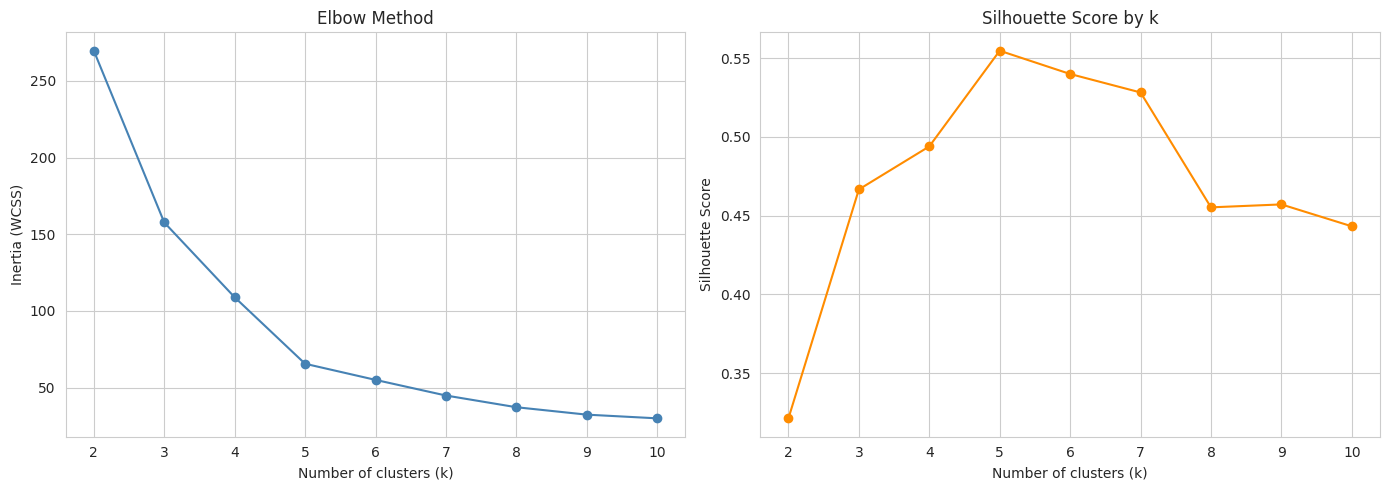

Best k by silhouette score: 5


In [30]:
inertia = []
silhouette = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia, marker="o", color="steelblue")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette, marker="o", color="darkorange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette))]
print(f"Best k by silhouette score: {best_k}")


For the classic Mall_Customers dataset, both metrics typically point to **k = 5**, which lines up with 5 visually distinct groups in the income/spending scatter plot. Adjust `k` below if your elbow/silhouette results suggest something different.

FIT K-MEANS WITH CHOSEN K

In [31]:
k = 5  # change this if your elbow/silhouette analysis suggests a different value

kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df["Cluster"].value_counts().sort_index())


Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


VISUALIZE THE CLUSTERS

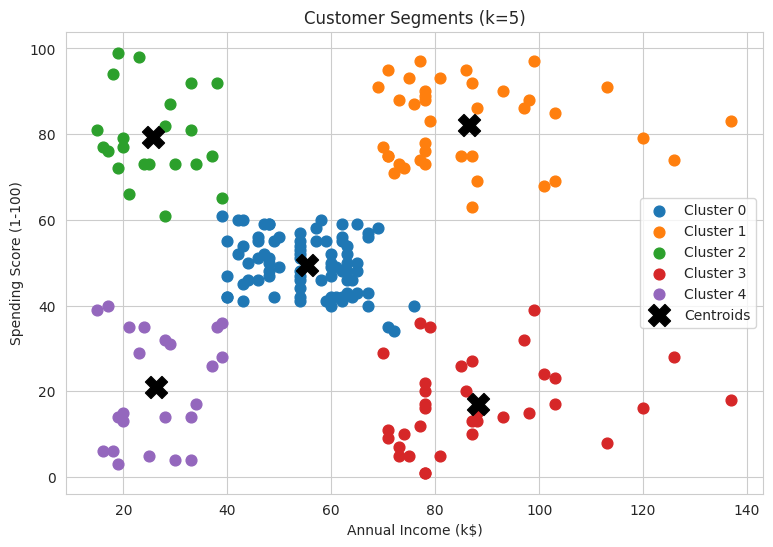

In [32]:
# Cluster centers back in original (unscaled) units, for plotting
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

plt.figure(figsize=(9, 6))
palette = sns.color_palette("tab10", k)

for cluster_id in range(k):
    cluster_data = df[df["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        s=60, color=palette[cluster_id], label=f"Cluster {cluster_id}"
    )

plt.scatter(
    centers_original[:, 0], centers_original[:, 1],
    s=250, c="black", marker="X", label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title(f"Customer Segments (k={k})")
plt.legend()
plt.show()


INTERPRET THE SEGMENTS

the average characteristics of each cluster to give them meaningful business labels (e.g. "high income, low spenders", "target customers", etc.).

In [33]:
cluster_summary = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_summary["Count"] = df["Cluster"].value_counts().sort_index()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


In [34]:
def label_cluster(row):
    income_high = row["Annual Income (k$)"] > df["Annual Income (k$)"].mean()
    spend_high = row["Spending Score (1-100)"] > df["Spending Score (1-100)"].mean()
    if income_high and spend_high:
        return "High Income, High Spending (Target)"
    elif income_high and not spend_high:
        return "High Income, Low Spending (Careful)"
    elif not income_high and spend_high:
        return "Low Income, High Spending (Impulsive)"
    elif not income_high and not spend_high:
        return "Low Income, Low Spending (Frugal)"
    else:
        return "Average Income, Average Spending"

cluster_summary["Segment Label"] = cluster_summary.apply(label_cluster, axis=1)
cluster_summary


,Age,Annual Income (k$),Spending Score (1-100),Count,Segment Label
Cluster,,,,,
0,42.7,55.3,49.5,81,"Low Income, Low Spending (Frugal)"
1,32.7,86.5,82.1,39,"High Income, High Spending (Target)"
2,25.3,25.7,79.4,22,"Low Income, High Spending (Impulsive)"
3,41.1,88.2,17.1,35,"High Income, Low Spending (Careful)"
4,45.2,26.3,20.9,23,"Low Income, Low Spending (Frugal)"


/tmp/ipykernel_1774/1239653192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", palette="tab10")


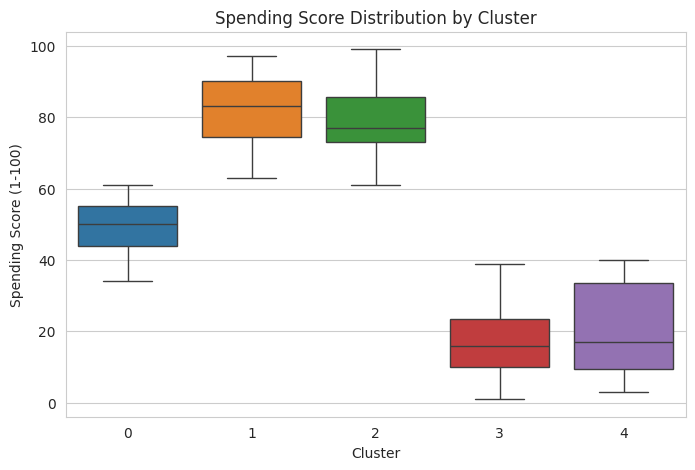

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", palette="tab10")
plt.title("Spending Score Distribution by Cluster")
plt.show()


3D CLUSTERING WITH AGE,INCOME AND SPENDING SCORE



Adding **Age** as a third dimension often reveals finer-grained segments (e.g. separating younger vs older high spenders).

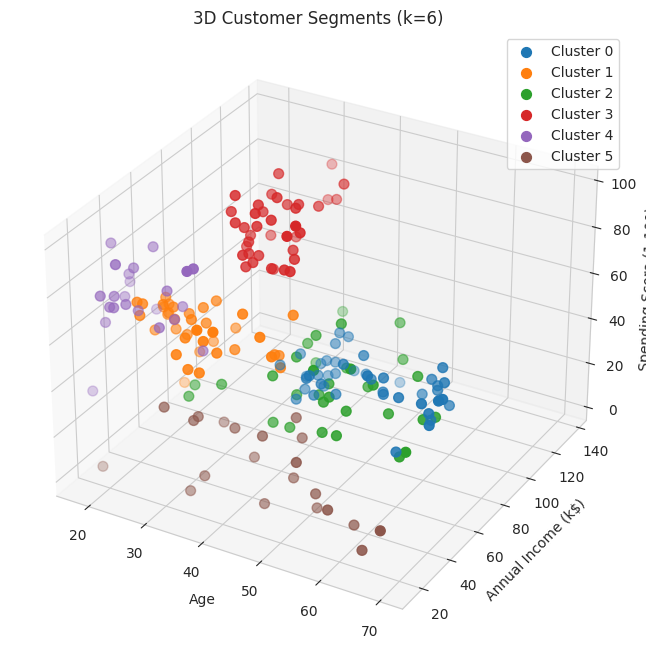

In [36]:
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X3 = df[features_3d].values
X3_scaled = StandardScaler().fit_transform(X3)

k3 = 6
kmeans_3d = KMeans(n_clusters=k3, init="k-means++", n_init=10, random_state=42)
df["Cluster_3D"] = kmeans_3d.fit_predict(X3_scaled)

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

palette3 = sns.color_palette("tab10", k3)
for cluster_id in range(k3):
    cluster_data = df[df["Cluster_3D"] == cluster_id]
    ax.scatter(
        cluster_data["Age"],
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        s=50, color=palette3[cluster_id], label=f"Cluster {cluster_id}"
    )

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
ax.set_title(f"3D Customer Segments (k={k3})")
ax.legend()
plt.show()


EXPORT RESULTS

Save the segmented customer data (with cluster labels) to a CSV — useful for handing off to a marketing team.

In [37]:
df.to_csv("Mall_Customers_segmented.csv", index=False)
print("Saved: Mall_Customers_segmented.csv")
df.head()


Saved: Mall_Customers_segmented.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster_3D
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,4
2,3,Female,20,16,6,4,5
3,4,Female,23,16,77,2,4
4,5,Female,31,17,40,4,5


In [38]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = kmeans.labels_

print("Silhouette Score:", silhouette_score(X_scaled, labels))       # higher is better (-1 to 1)
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, labels)) # lower is better
print("Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, labels)) # higher is better
print("Inertia (WCSS):", kmeans.inertia_)                              # lower is better


Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352
Calinski-Harabasz Index: 248.64932001536357
Inertia (WCSS): 65.56840815571681
